<a href="https://colab.research.google.com/github/areebaarshadqureshi/Data-Science-Journey-CampusX/blob/main/07-Pandas/04-Merging-Joining-and-Concatenating/Merging_Joining_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

###`Q-1:` You are given a Multi index DataFrame. You task is to swap level-0 index with level-0 column.
* Change Branch -> ('cse', 'ece') as columns at level-0 and ('delhi'	'mumbai') as level-0 Index
* And Sort on row index level-0

In [ ]:
# Given Code Snippets
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
df = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

df

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [ ]:
df.columns = df.columns.swaplevel(0,1)
df

avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

###`Q-2:` Covid Cases Data Set Problem
 Make a DataFrame Using both Covid Dataset. With Country name as Level-0 and Provinance/State as Level-1 Index and date, No of cases and No of Deaths as Columns.

In [ ]:
confirm = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vTmqT3kxd0i0RUFiEnwA1Hboiunv28MeNTatZsIEqlPPB7mHrl0ttJL7utZ23_1s5FW8ZjODmB8jHIi/pub?gid=2142019845&single=true&output=csv')

deaths = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQn4nLCKIVZMw4e89YeRqgKaSAAwRFaZ6ILMW_FUejZ2tkv3Np1f9gD4QOl3ASHeLzWjOjfmLDKcCOF/pub?gid=212966958&single=true&output=csv")

###`Q-3:` Show Country with Heighest death percent out of confirmed Cases.

In [ ]:
confirm.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [ ]:
deaths.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [ ]:
confirm=confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='Date',value_name='Confirmed')
deaths=deaths.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='Date',value_name='Deaths')

In [ ]:
data=confirm.merge(deaths,on=['Province/State','Country/Region','Lat','Long','Date'])
data.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0,0


In [ ]:
import numpy as np
country_data=round(data.groupby('Country/Region')['Deaths'].sum()/data.groupby('Country/Region')['Confirmed'].sum()*100,2)
country_data.reset_index(name='%age').sort_values(by='%age',ascending=False).head(1)


,Country/Region,%age
93,"Korea, North",600.0


### `Q-4` : Make a dataframe for India from Covid Data with one extra column representing no of new cases.

* Just for Assumption "No of new cases" will be equal to difference of "no of cases" with previous day.
* First day new cases will be NaN or equal to no of cases

Say on 12/30/22 No of cases is - 44679608	and a day previous (12/29/22) no of cases is - 44679382.

Then for 12/30/22 -> No of New Cases  = 44679608 - 44679382 =

Note:- Try using shift Function

Try using the shift function

```
s = pd.Series([1,2,3,4,5,6])
s #-> [1,2,3,4,5,6]
s.shift(1) #-> [NaN, 1,2,3,4,5]
s.shift(-1) #-> [2,3,4,5,6, NaN]
```

In [ ]:
# Filter the data for India
I_data = data[data['Country/Region'] == 'India']

# Group by Date and sum Confirmed cases (in case multiple entries per date)
I_data = I_data.groupby('Date')[['Confirmed']].sum()

# Sort by date to ensure chronological correctness
I_data.sort_index(inplace=True)

# Calculate "No of New Cases" using shift
I_data['No of New Cases'] = I_data['Confirmed'] - I_data['Confirmed'].shift(1)

# Optional: Fill the first NaN with actual confirmed cases (as per assumption)
I_data['No of New Cases'].fillna(I_data['Confirmed'], inplace=True)

# Reset index if you want 'Date' as a column
I_data = I_data.reset_index()

# Display result
I_data.head()


/tmp/ipython-input-3895460433.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  I_data['No of New Cases'].fillna(I_data['Confirmed'], inplace=True)


,Date,Confirmed,No of New Cases
0,1/1/21,10305788,10305788.0
1,1/1/22,34889132,24583344.0
2,1/1/23,44680046,9790914.0
3,1/10/21,10466595,-34213451.0
4,1/10/22,35875790,25409195.0


### `Q-5:` Read the Dataset using the below given link and create a multi-index dataframe using the columns "Country" and "City/Town".

This dataset is about the most polluted cities in the world. You can get details from [here](https://www.kaggle.com/datasets/rajkumarpandey02/worlds-most-air-polluted-countries-cities).

**Dataset link:** https://tinyurl.com/2fe6vz4u Directly use this link to read.

**Task:**
1. Find out the name of the city of India which is most poluted based on PM10.
2. Find out the name of the city of India which has minumum pollution level based on PM10.
3. Do same operations (like 1 and 2) with the country China.
4. Make a pie chart based on the column "PM10" of the country Poland.
5. Make a bar chart based on the columns "PM2.5" and "PM10" of the countries Israel and Qatar.
6. Convert this MultiIndex DataFrame to Series by retaining the informations.

In [ ]:
df=pd.read_csv('/content/List of most-polluted cities by particulate matter concentration - List of most-polluted cities by particulate matter concentration.csv')

In [ ]:
df.head(3)

,Unnamed: 0,Position,Country,City/Town,Year,PM2.5,Temporal coverage,PM10,Temporal coverage.1,Database version (year)
0,0,1,India,Kanpur,2016,173,>75%,319,NaN,2018
1,1,2,India,Faridabad,2016,172,>75%,316,NaN,2018
2,2,3,India,Gaya,2016,149,50% -< 75%,275,NaN,2018


In [ ]:
data=df[df['Country']=='India']
res=data.pivot_table(index='City/Town',values='PM10',aggfunc='sum')
res.sort_values(by='PM10',ascending=False).head(1)


,PM10
City/Town,
Kanpur,319
Faridabad,316
Delhi,292
Gaya,275
Patna,266
Varanasi,260
Lucknow,255
Muzaffarpur,221
Agra,194


In [ ]:
data = df[df['Country'] == 'India']
res = data.pivot_table(index='City/Town', values='PM10', aggfunc='sum')
res.sort_values(by='PM10', ascending=True).head(1)


,PM10
City/Town,
Aizawl,44


In [ ]:
data=df[df['Country']=='China']
res=data.pivot_table(index='City/Town',values='PM10',aggfunc='sum')
res.sort_values(by='PM10',ascending=False).head(1)


,PM10
City/Town,
Jinan,333


In [ ]:
res.sort_values(by='PM10', ascending=True).head(1)

,PM10
City/Town,
Anshun,38


<Axes: ylabel='PM10'>

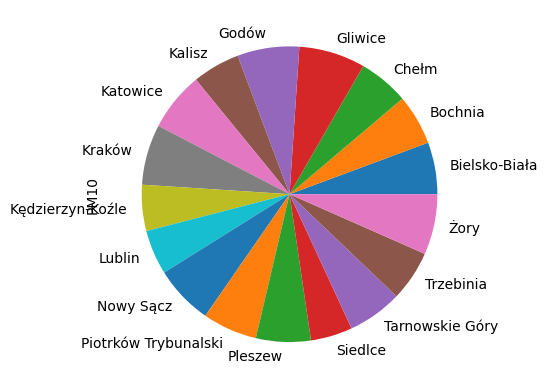

In [ ]:
data=df[df['Country']=='Poland']
res=data.pivot_table(index='City/Town',values='PM10',aggfunc='sum')
res['PM10'].plot(kind='pie')

<Axes: xlabel='Country'>

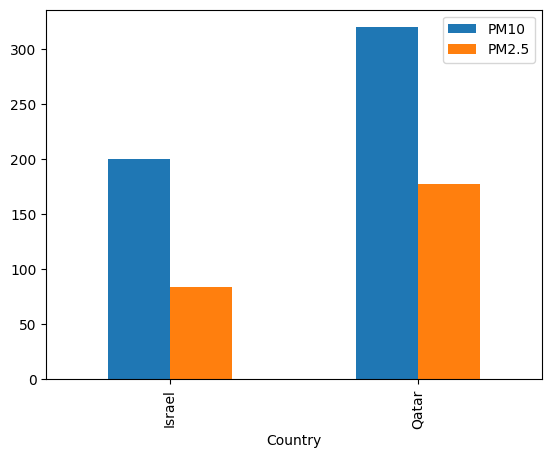

In [ ]:
res_data=df[(df['Country']=='Israel')|(df['Country']=='Qatar')]
res=res_data.pivot_table(index='Country',values=['PM2.5','PM10'],aggfunc='sum')
res.plot(kind='bar')


In [ ]:
res.stack()

Country       
Israel   PM10     200
         PM2.5     84
Qatar    PM10     320
         PM2.5    178
dtype: int64